# Семинар 2. Ван-дер-Поль: разбираем численное решение

На прошлой паре мы уже решили уравнение Ван-дер-Поля численно, построили $x(t)$ и фазовые траектории и увидели, что решения выходят на предельный цикл.

Сегодня продолжим с той же системой и попробуем получить из численного решения не только картинки, но и конкретные характеристики: амплитуду, период, переходный участок и зависимость поведения от $\mu$.

Рассматриваем
$$
x''-\mu(1-x^2)x'+x=0,\qquad \mu > 0,
$$
или, после замены $y=x'$,
$$
\begin{cases}
x'=y,\\
y'=\mu(1-x^2)y-x.
\end{cases}
$$

В некоторых местах сначала ответьте на вопрос, а уже потом запускайте следующую ячейку.

Численные результаты не берём «на глаз»: если в выводе указано конкретное значение, оно должно быть посчитано в notebook.

## 0. Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

## 1. Разбираем результат `solve_ivp`

Сначала ещё раз решим уже знакомую задачу:
$$
\mu=1,\qquad x(0)=0.1,\qquad y(0)=0.
$$

Перед запуском посмотрите на функцию `vdp` и ответьте:

1. Что лежит в `state`?
2. Что должна вернуть функция?
3. Сколько строк вы ожидаете увидеть в `sol.y`?

<span style="color:red">Ответ:</span>
1. переменные x и y
2. производные x' и y', т.е. правую часть системы
3. 2 строки

In [2]:
def vdp(t, state, mu):
    x, y = state
    return [y, mu * (1 - x**2) * y - x]


mu = 1.0
t_eval = np.linspace(0, 60, 6001)

sol = solve_ivp(
    vdp,
    t_span=(0, 60),
    y0=[0.1, 0.0],
    t_eval=t_eval,
    args=(mu,),
    rtol=1e-8,
    atol=1e-10,
)

print("success:", sol.success)
print("sol.t.shape =", sol.t.shape)
print("sol.y.shape =", sol.y.shape)

success: True
sol.t.shape = (6001,)
sol.y.shape = (2, 6001)


### Индексация

Запустите следующую ячейку и разберите, что выдаёт каждая строка.

Особенно обратите внимание на разницу между

- `sol.y[0]`,
- `sol.y[:, 0]`,
- `sol.y[:, -1]`.

In [3]:
x = sol.y[0]
y = sol.y[1]

print("Первые 5 моментов времени:", sol.t[:5])
print("Первые 5 значений x(t):", x[:5])
print("Начальное состояние:", sol.y[:, 0])
print("Конечное состояние:", sol.y[:, -1])

Первые 5 моментов времени: [0.   0.01 0.02 0.03 0.04]
Первые 5 значений x(t): [0.1        0.09999498 0.09997987 0.09995455 0.09991894]
Начальное состояние: [0.1 0. ]
Конечное состояние: [ 1.53011576 -0.76804887]


### Быстрая проверка

Ответьте без дополнительного кода:

1. Какой `shape` у `sol.y`?
2. Что означают две координаты этого массива?
3. Как получить $y$ в последний момент времени?
4. Почему `sol.y[0, -1]` — число, а `sol.y[0]` — массив?

## 2. Отбрасываем переходный участок

В начале решение ещё выходит на установившийся режим. Эту часть дальше не будем использовать для оценки характеристик цикла.

Оставим только точки при $t\ge 20$.

Перед запуском: что находится в `mask` — числа, индексы или логические значения?

<span style="color:red">Ответ:</span>
1. (2, 6001)
2. первая координата - номер переменной (x или y), вторая - номер момента времени
3. sol.y[1, -1]
4. sol.y[0, -1] выбирает один элемент массива - значение x в последний момент времени, а sol.y[0] выбирает всю первую строку, то есть все значения x(t)

в `mask` - логические значения

In [4]:
mask = sol.t >= 20

print("type(mask) =", type(mask))
print("mask.shape =", mask.shape)
print("Первые элементы mask:", mask[:8])
print("Последние элементы mask:", mask[-8:])

t_ss = sol.t[mask]
x_ss = x[mask]
y_ss = y[mask]

print("Число точек после t=20:", len(t_ss))

type(mask) = <class 'numpy.ndarray'>
mask.shape = (6001,)
Первые элементы mask: [False False False False False False False False]
Последние элементы mask: [ True  True  True  True  True  True  True  True]
Число точек после t=20: 4001


### Амплитуда

Для почти симметричного периодического сигнала оценим амплитуду как
$$
A\approx\frac{\max x-\min x}{2}.
$$

После запуска вернитесь к предыдущей ячейке, замените `20` на `30` и сравните результат.

Почему после окончания переходного процесса оценка амплитуды почти не меняется?

In [5]:
amplitude = (x_ss.max() - x_ss.min()) / 2
center = (x_ss.max() + x_ss.min()) / 2

print(f"amplitude ≈ {amplitude:.6f}")
print(f"center ≈ {center:.6f}")

amplitude ≈ 2.008619
center ≈ -0.000000


<span style="color:red">Ответ:</span>

1. после окончания переходного процесса решение выходит на устойчивый предельный цикл, поэтому максимумы и минимумы почти не меняются и оценка амплитуды остаётся практически постоянной

### Сравните полную траекторию и установившийся цикл

Постройте **два фазовых портрета рядом**:

1. всю траекторию на интервале $0\le t\le 60$;
2. только часть при $t\ge 20$.

На первом рисунке отметьте начальную точку с помощью `plt.scatter`.

Для обоих рисунков используйте одинаковый масштаб (`axis("equal")`) и одинаковые пределы осей.

После построения ответьте:

- какая часть траектории исчезла на втором рисунке;
- какой из двух графиков лучше показывает форму предельного цикла;
- заметно ли изменится второй график, если вместо $t\ge20$ взять $t\ge30$.

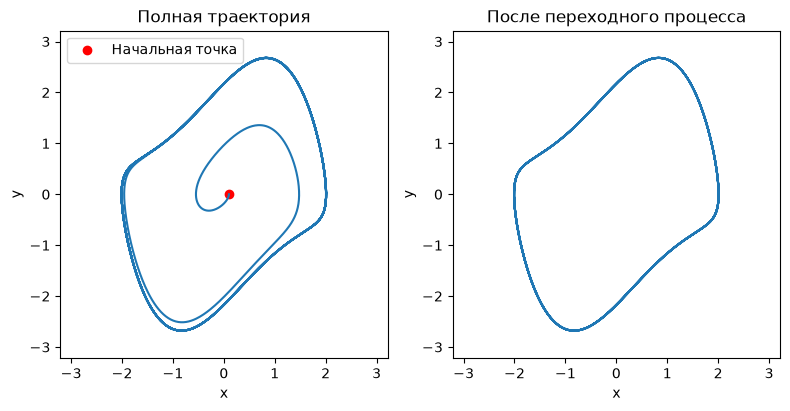

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8, 8))

axes[0].plot(x, y)
axes[0].scatter(x[0], y[0], color='red', label='Начальная точка')
axes[0].set_title('Полная траектория')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()

axes[1].plot(x_ss, y_ss)
axes[1].set_title('После переходного процесса')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

limit = 1.2 * max(
    np.max(np.abs(x)),
    np.max(np.abs(y))
)

for ax in axes:
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

<span style="color:red">Ответ:</span>

1. на втором рисунке исчезает переходная часть траектории, по которой решение из начальной точки выходит на предельный цикл
2. второй график лучше показывает форму предельного цикла, потому что на нём нет переходного процесса
3. при замене $t\ge20$ на $t\ge30$ второй график заметно не изменится, так как к этому моменту решение уже практически вышло на предельный цикл

### Центр и амплитуда на графике $x(t)$

По установившейся части решения мы уже посчитали
$$
c=\frac{x_{\max}+x_{\min}}{2},
\qquad
A=\frac{x_{\max}-x_{\min}}{2}.
$$

Теперь постройте $x(t)$ на всём интервале $0\le t\le60$ и добавьте три горизонтальные линии:
$$
x=c,\qquad x=c+A,\qquad x=c-A.
$$

Линии $c+A$ и $c-A$ должны проходить примерно по уровням установившихся максимумов и минимумов.

Ещё одной вертикальной пунктирной линией отметьте $t=20$ — момент, после которого мы оставляли решение для дальнейших расчётов.

Подпишите линии в легенде.

Ответьте:

1. почему $c$ и $A$ лучше считать после удаления переходного участка;
2. действительно ли $c+A$ и $c-A$ совпадают с уровнями установившихся максимумов и минимумов;
3. что произойдёт с оценкой амплитуды, если взять, например, $x(0)=5$ и считать `max` и `min` по всей траектории.

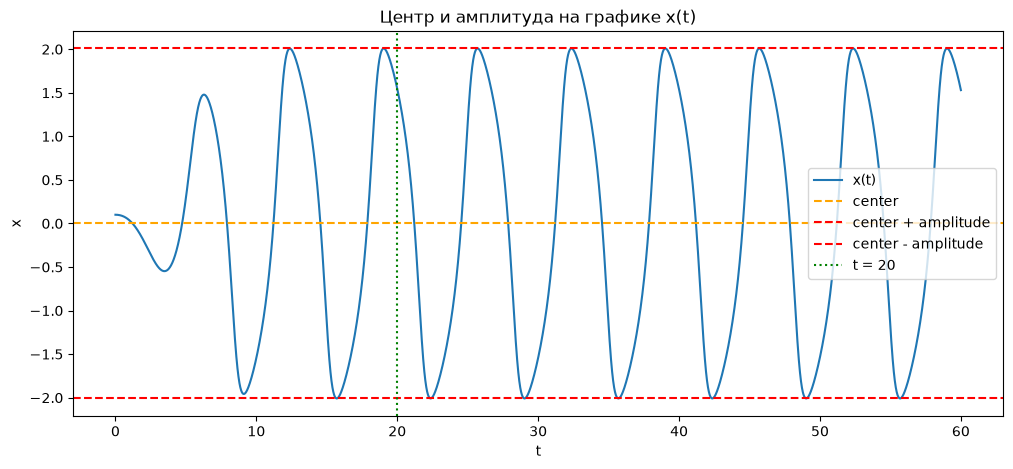

In [7]:
# TODO: постройте x(t) и добавьте линии:
# center,
# center + amplitude,
# center - amplitude,
# а также вертикальную линию t = 20.

plt.figure(figsize=(12, 5))

plt.plot(sol.t, x, label='x(t)')

plt.axhline(center, linestyle='--', label='center', color='orange')
plt.axhline(center + amplitude, linestyle='--', label='center + amplitude', color='red')
plt.axhline(center - amplitude, linestyle='--', label='center - amplitude', color='red')

plt.axvline(20, linestyle=':', label='t = 20', color='green')

plt.xlabel('t')
plt.ylabel('x')
plt.title('Центр и амплитуда на графике x(t)')
plt.legend()

plt.show()


<span style="color:red">Ответ:</span>

1. $c$ и $A$ лучше считать после удаления переходного участка, потому что в начале решение ещё не вышло на установившийся режим и амплитуда колебаний меняется

2. по определению $c+A=x_{\max}$ и $c-A=x_{\min}$ на выбранном участке, поэтому они совпадают с его максимальным и минимальным уровнями, а с отдельными локальными максимумами и минимумами совпадают практически

3. если взять $x(0)=5$ и считать максимум и минимум по всей траектории, переходный участок попадёт в расчёт и оценка амплитуды может получиться завышенной

## 3. Оцениваем период

Период можно примерно оценить по графику, но нам нужна численная величина.

Найдём локальные максимумы $x(t)$. Функция `find_peaks` возвращает их **индексы**.

In [8]:
peaks, _ = find_peaks(x_ss, prominence=0.5)

peak_times = t_ss[peaks]
peak_values = x_ss[peaks]

print("Последние времена максимумов:")
print(peak_times[-6:])

print("\nПоследние значения максимумов:")
print(peak_values[-6:])

Последние времена максимумов:
[25.7  32.36 39.03 45.69 52.35]

Последние значения максимумов:
[2.00861913 2.00861387 2.00860158 2.00861888 2.00861454]


Перед следующей ячейкой ответьте:

1. Что вернёт `np.diff(peak_times)`?
2. Если решение уже вышло на цикл, что должно происходить с этими разностями?

<span style="color:red">Ответ:</span>

1. `np.diff(peak_times)` вернёт разности между соседними моментами времени максимумов, то есть оценки периода колебаний

2. после выхода решения на предельный цикл эти разности должны стать практически постоянными и стремиться к периоду установившихся колебаний

In [9]:
periods = np.diff(peak_times)

print("Последние оценки периода:")
print(periods[-5:])

period = periods[-5:].mean()
period_std = periods[-5:].std()

print(f"Средний период T ≈ {period:.6f}")
print(f"Разброс последних периодов ≈ {period_std:.2e}")

Последние оценки периода:
[6.66 6.67 6.66 6.66]
Средний период T ≈ 6.662500
Разброс последних периодов ≈ 4.33e-03


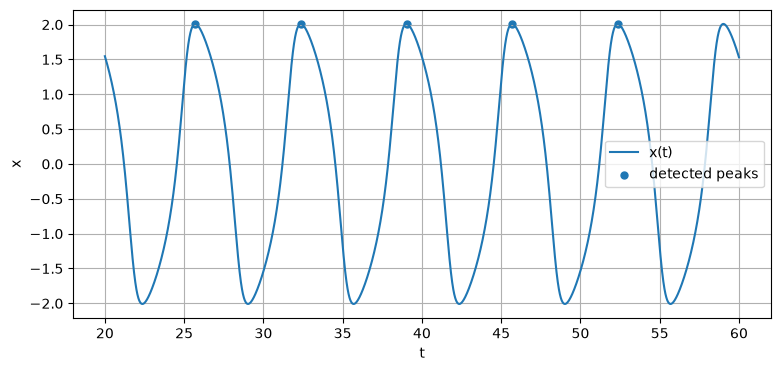

In [10]:
plt.figure(figsize=(9, 4))
plt.plot(t_ss, x_ss, label="x(t)")
plt.scatter(peak_times, peak_values, s=25, label="detected peaks")
plt.xlabel("t")
plt.ylabel("x")
plt.grid()
plt.legend()
plt.show()

### Быстрая проверка

Покажите найденные $A$ и $T$ и ответьте:

1. Почему период лучше оценивать по нескольким последним максимумам, а не по первым двум?
2. Что изменится, если сделать `t_eval` заметно плотнее?
3. Изменится ли от этого само решение дифференциального уравнения?

In [11]:
print(f"A ≈ {amplitude:.6f}")
print(f"T ≈ {period:.6f}")

A ≈ 2.008619
T ≈ 6.662500


<span style="color:red">Ответ:</span>

1. период лучше оценивать по нескольким последним максимумам, потому что первые максимумы могут относиться к переходному процессу, когда колебания ещё не установились

2. при более плотном `t_eval` будет больше точек решения, поэтому положения максимумов и оценки $A$ и $T$ можно определить точнее

3. само решение дифференциального уравнения не изменится, так как `t_eval` задаёт только точки, в которых сохраняется найденное решение, а не меняет само уравнение

## 4. Что меняется при изменении $\mu$

Теперь повторим один и тот же расчёт для нескольких значений параметра.

Напишем функцию, которая для заданного $\mu$:

- решает систему;
- отбрасывает переходный участок;
- оценивает амплитуду;
- оценивает период.

In [12]:
def cycle_stats(mu, t_end=160, t_cut=100):
    t_eval = np.linspace(0, t_end, 12001)

    sol_mu = solve_ivp(
        vdp,
        (0, t_end),
        [0.1, 0.0],
        t_eval=t_eval,
        args=(mu,),
        rtol=1e-8,
        atol=1e-10,
    )

    mask = sol_mu.t >= t_cut
    t = sol_mu.t[mask]
    x = sol_mu.y[0, mask]

    amplitude = (x.max() - x.min()) / 2

    peaks, _ = find_peaks(x, prominence=0.5)
    peak_times = t[peaks]
    period = np.diff(peak_times[-6:]).mean()

    return amplitude, period

Сначала попробуйте предсказать результат для
$$
\mu=0.2,\;0.5,\;1,\;2,\;5.
$$

Как, по-вашему, будут меняться амплитуда и период? Сначала сформулируйте предположение, потом запускайте расчёт.

<span style="color:red">Ответ:</span>

1. амплитуда при увеличении $\mu$ должна меняться незначительно и оставаться примерно постоянной
2. период при увеличении $\mu$ должен возрастать

In [13]:
mu_values = [0.2, 0.5, 1.0, 2.0, 5.0]

results = []

for mu_value in mu_values:
    A, T = cycle_stats(mu_value)
    results.append((mu_value, A, T))

for mu_value, A, T in results:
    print(f"mu={mu_value:>3}:  A≈{A:.5f},  T≈{T:.5f}")

mu=0.2:  A≈2.00041,  T≈6.29867
mu=0.5:  A≈2.00249,  T≈6.38133
mu=1.0:  A≈2.00862,  T≈6.66133
mu=2.0:  A≈2.01989,  T≈7.62933
mu=5.0:  A≈2.02151,  T≈11.61333


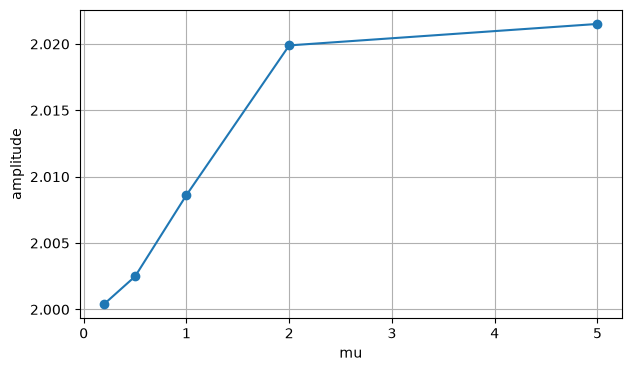

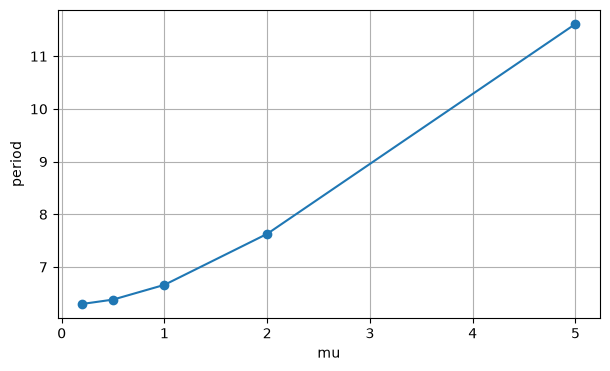

In [14]:
results_array = np.array(results)

plt.figure(figsize=(7, 4))
plt.plot(results_array[:, 0], results_array[:, 1], "o-")
plt.xlabel("mu")
plt.ylabel("amplitude")
plt.grid()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(results_array[:, 0], results_array[:, 2], "o-")
plt.xlabel("mu")
plt.ylabel("period")
plt.grid()
plt.show()

## 5. Как меняется форма предельного цикла

По графикам $A(\mu)$ и $T(\mu)$ видно, как меняются две численные характеристики, но не видно самой формы цикла.

Построим установившиеся фазовые траектории для нескольких значений $\mu$ на одном рисунке.

Перед запуском подумайте: при росте $\mu$ цикл просто увеличивается или в первую очередь меняется его форма?

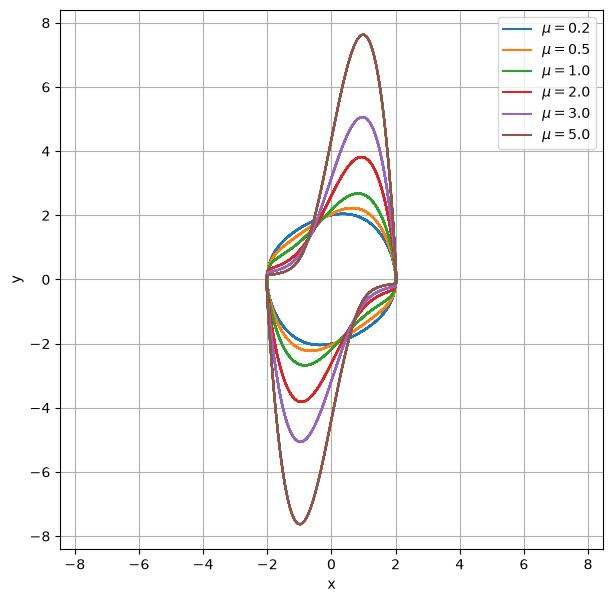

In [15]:
def settled_cycle(mu, t_end=200, t_cut=120):
    t_eval = np.linspace(0, t_end, 15001)

    sol_mu = solve_ivp(
        vdp,
        (0, t_end),
        [0.1, 0.0],
        t_eval=t_eval,
        args=(mu,),
        rtol=1e-8,
        atol=1e-10,
    )

    mask = sol_mu.t >= t_cut
    return sol_mu.y[0, mask], sol_mu.y[1, mask]


mu_for_phase_plot = [0.2, 0.5, 1.0, 2.0, 3.0, 5.0]

plt.figure(figsize=(7, 7))

for mu_value in mu_for_phase_plot:
    x_cycle, y_cycle = settled_cycle(mu_value)
    plt.plot(x_cycle, y_cycle, label=fr"$\mu={mu_value}$")

plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

### В конце пары

1. Добавьте в список `mu = 3.0` и перестройте рисунок.
2. Что меняется заметнее: максимальное значение $|x|$ или форма фазовой кривой?
3. Почему перед построением цикла мы отбрасываем начальный участок траектории?
4. Зачем здесь понадобилась отдельная функция `settled_cycle`?

Если останется время, замените начальное условие `[0.1, 0.0]` на `[3.0, 0.0]` и сравните установившиеся циклы.

---

## Что из Python здесь использовалось

За пару встретились:

- индексация NumPy-массивов;
- `shape` и булевы маски;
- `max`, `min`, `np.diff`;
- поиск пиков;
- функции;
- цикл по значениям параметра;
- Matplotlib для сравнения нескольких расчётов.

Все эти вещи дальше будут регулярно встречаться в задачах с численным решением ОДУ и оптимизацией.

<span style="color:red">Ответ:</span>

1. при добавлении $\mu=3$ получается промежуточная по форме фазовая кривая между случаями $\mu=2$ и $\mu=5$
2. максимальное значение $|x|$ меняется незначительно, заметнее меняется форма фазовой кривой
3. начальный участок отбрасываем, потому что он соответствует переходному процессу, а нас интересует установившийся предельный цикл
4. функция `settled_cycle` нужна, чтобы для разных значений $\mu$ одним и тем же способом находить установившуюся часть траектории и не дублировать одинаковый код

# Домашняя работа — срок 2 недели

Домашку делайте в этом же notebook: допишите ячейки ниже, используя функции и код, которые уже есть выше.

Не делайте отдельный кусок кода для каждого значения $\mu$ или начального условия. Если одно и то же действие повторяется, используйте цикл или функцию.

## 1. Амплитуда и период как функции $\mu$

Возьмите не менее **20 значений**
$$
\mu\in[0.2,5].
$$

Для каждого значения найдите:

- амплитуду $A(\mu)$;
- период $T(\mu)$.

Постройте графики
$$
A(\mu), \qquad T(\mu).
$$

После графиков ответьте:

1. какая из двух величин меняется с ростом $\mu$ сильнее;
2. монотонны ли полученные зависимости;
3. есть ли диапазон $\mu$, где характер изменения особенно заметен.

Все значения должны считаться кодом.

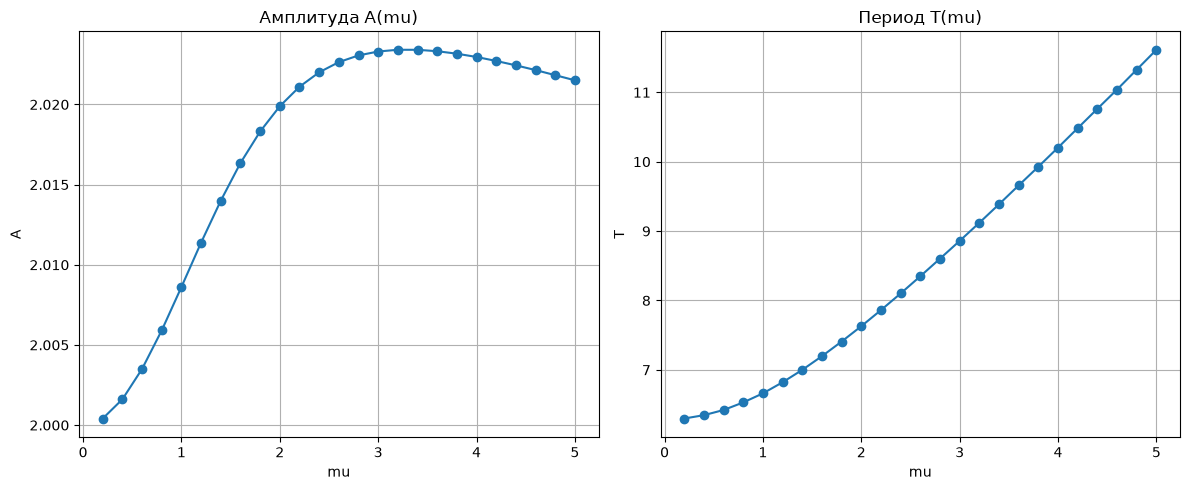

In [16]:
# Ваш код для задания 1
mu_values = np.linspace(0.2, 5.0, 25)

amplitudes = []
periods = []

for mu_value in mu_values:
    A, T = cycle_stats(mu_value)
    amplitudes.append(A)
    periods.append(T)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(mu_values, amplitudes, marker='o')
axes[0].set_xlabel('mu')
axes[0].set_ylabel('A')
axes[0].set_title('Амплитуда A(mu)')
axes[0].grid()

axes[1].plot(mu_values, periods, marker='o')
axes[1].set_xlabel('mu')
axes[1].set_ylabel('T')
axes[1].set_title('Период T(mu)')
axes[1].grid()

plt.tight_layout()
plt.show()

<span style="color:red">Ответ:</span>

1. с ростом $\mu$ значительно сильнее меняется период $T$, тогда как амплитуда $A$ изменяется слабо
2. зависимость $T(\mu)$ монотонно возрастает, а $A(\mu)$ не монотонна: сначала она растёт, а затем начинает немного уменьшаться
3. для амплитуды в средней части рассматриваемого диапазона рост сменяется слабым уменьшением, а период с увеличением $\mu$ растёт всё быстрее

## 2. Форма предельного цикла при разных $\mu$

На одном фазовом рисунке постройте установившиеся циклы для
$$
\mu=0.2,\quad 0.5,\quad 1,\quad 2,\quad 3,\quad 5.
$$

Используйте `plt.axis("equal")`.

После рисунка ответьте:

1. сильно ли меняется максимальное значение $|x|$;
2. как меняется форма цикла;
3. что видно на фазовом рисунке, чего не видно на графиках $A(\mu)$ и $T(\mu)$.

Затем отдельно для $\mu=0.2$ и $\mu=5$ постройте $x(t)$ на нескольких последних периодах и сравните вид временного сигнала с фазовым портретом.

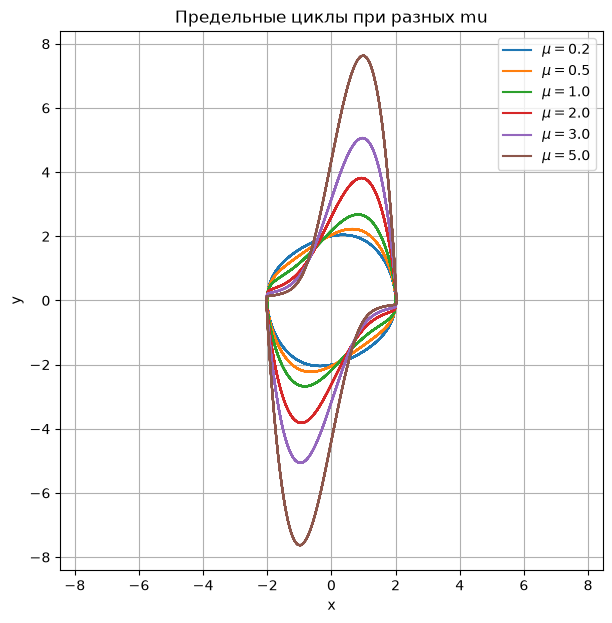

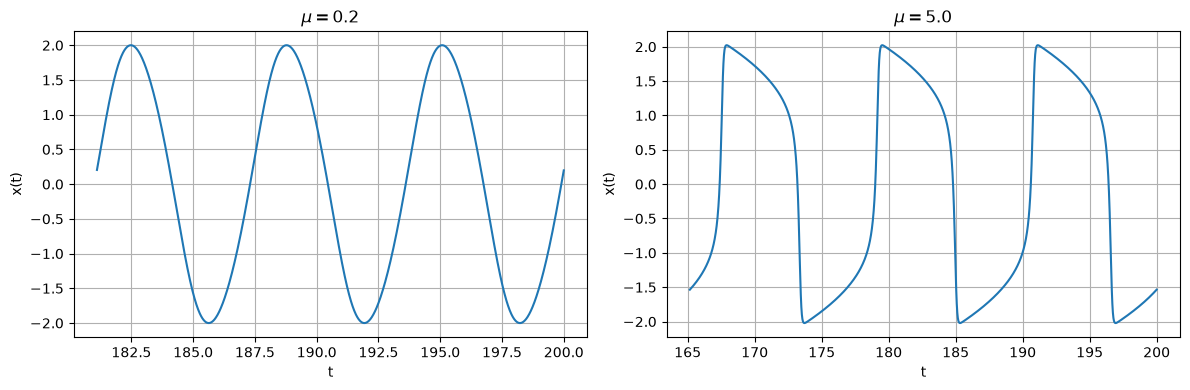

In [17]:
# Ваш код для задания 2
mu_values = [0.2, 0.5, 1.0, 2.0, 3.0, 5.0]

plt.figure(figsize=(7, 7))

for mu_value in mu_values:
    x_cycle, y_cycle = settled_cycle(mu_value)
    plt.plot(x_cycle, y_cycle, label=fr"$\mu={mu_value}$")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Предельные циклы при разных mu")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, mu_value in zip(axes, [0.2, 5.0]):
    _, T = cycle_stats(mu_value)

    t_end = 200
    t_eval = np.linspace(0, t_end, 15001)

    sol_mu = solve_ivp(
        vdp,
        (0, t_end),
        [0.1, 0.0],
        t_eval=t_eval,
        args=(mu_value,),
        rtol=1e-8,
        atol=1e-10,
    )

    mask = sol_mu.t >= t_end - 3 * T

    ax.plot(sol_mu.t[mask], sol_mu.y[0, mask])
    ax.set_title(fr"$\mu={mu_value}$")
    ax.set_xlabel("t")
    ax.set_ylabel("x(t)")
    ax.grid()

plt.tight_layout()
plt.show()

<span style="color:red">Ответ:</span>

1. максимальное значение $|x|$ меняется слабо при изменении $\mu$
2. при увеличении $\mu$ форма предельного цикла заметно меняется: из почти овальной она становится всё более вытянутой по оси $y$, появляются участки с быстрым изменением состояния
3. на фазовом рисунке видно изменение геометрической формы цикла и сильный рост значений $|y|$, чего нельзя увидеть только по графикам $A(\mu)$ и $T(\mu)$
4. при $\mu=0.2$ сигнал $x(t)$ близок к синусоидальному, а при $\mu=5$ колебания становятся релаксационными: появляются участки медленного изменения $x$ и быстрые переходы между ними

## 3. Как быстро решение выходит на цикл

Возьмите $\mu=1$ и начальные условия
$$
(0.1,0),\qquad (1,0),\qquad (3,0),\qquad (4,2).
$$

Для каждого решения найдите последовательность положительных максимумов $x(t)$ с помощью `find_peaks`.

Постройте один график:

- по горизонтальной оси — номер максимума;
- по вертикальной — его значение.

На рисунке должны быть четыре кривые.

За установившееся значение для каждой траектории возьмите среднее последних пяти максимумов. Найдите первый максимум, после которого все следующие отличаются от этого значения менее чем на **1%**.

Ответьте:

1. одинаково ли быстро разные начальные условия выходят на цикл;
2. зависит ли сам установившийся цикл от начального условия;
3. почему одного фазового портрета недостаточно, чтобы сравнить скорость выхода на цикл.

y0=(0.1, 0.0): установившийся максимум ≈ 2.008609, выход с максимума №2
y0=(1.0, 0.0): установившийся максимум ≈ 2.008612, выход с максимума №1
y0=(3.0, 0.0): установившийся максимум ≈ 2.008612, выход с максимума №1
y0=(4.0, 2.0): установившийся максимум ≈ 2.008611, выход с максимума №2


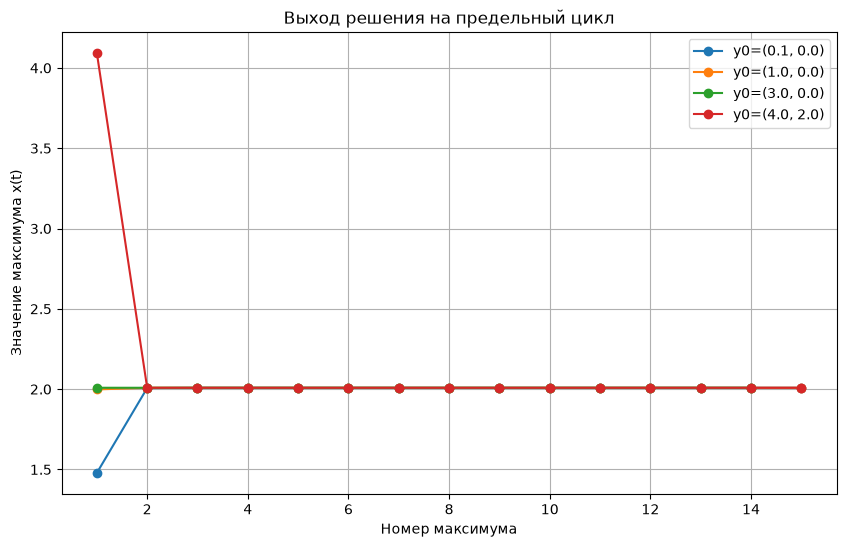

In [18]:
# Ваш код для задания 3
mu = 1.0
initial_conditions = [
    (0.1, 0.0),
    (1.0, 0.0),
    (3.0, 0.0),
    (4.0, 2.0),
]

t_eval = np.linspace(0, 100, 10001)

plt.figure(figsize=(10, 6))

for y0 in initial_conditions:
    sol_ic = solve_ivp(
        vdp,
        (0, 100),
        y0,
        t_eval=t_eval,
        args=(mu,),
        rtol=1e-8,
        atol=1e-10,
    )

    x_ic = sol_ic.y[0]

    peaks, properties = find_peaks(x_ic, height=0)
    peak_values = x_ic[peaks]

    steady_value = peak_values[-5:].mean()

    relative_errors = np.abs(
        peak_values - steady_value
    ) / np.abs(steady_value)

    convergence_index = None

    for i in range(len(peak_values)):
        if np.all(relative_errors[i:] < 0.01):
            convergence_index = i + 1
            break

    peak_numbers = np.arange(1, len(peak_values) + 1)

    plt.plot(
        peak_numbers,
        peak_values,
        marker='o',
        label=f'y0={y0}'
    )

    print(
        f'y0={y0}: '
        f'установившийся максимум ≈ {steady_value:.6f}, '
        f'выход с максимума №{convergence_index}'
    )

plt.xlabel('Номер максимума')
plt.ylabel('Значение максимума x(t)')
plt.title('Выход решения на предельный цикл')
plt.grid()
plt.legend()
plt.show()

<span style="color:red">Ответ:</span>

1. разные начальные условия выходят на предельный цикл не одинаково быстро: для $(1,0)$ и $(3,0)$ уже первый найденный максимум отличается от установившегося значения менее чем на $1\%$, а для $(0.1,0)$ и $(4,2)$ это происходит со второго максимума
2. от начального условия зависит длительность переходного процесса, но после выхода на цикл все решения стремятся к одному и тому же установившемуся режиму
3. одного фазового портрета недостаточно, потому что он показывает форму траектории, но не показывает, за сколько максимумов или за какое время решение приближается к предельному циклу

## 4. Период двумя способами

На семинаре мы оценивали период по расстоянию между соседними максимумами $x(t)$.

Теперь найдите его другим способом — по последовательным пересечениям прямой
$$
x=0
$$
в одном направлении.

В `solve_ivp` для этого есть `events`.

Подсказка:

```python
def x_zero(t, state, mu):
    return state[0]

x_zero.direction = 1
x_zero.terminal = False
```

Для
$$
\mu=0.5,\quad 1,\quad 3,\quad 5
$$
оцените период:

1. по максимумам через `find_peaks`;
2. по событиям `solve_ivp`.

В обоих случаях используйте несколько **последних** периодов после окончания переходного процесса.

Составьте таблицу с колонками

`mu`, `T_peaks`, `T_events`, `relative_difference`.

Последнюю колонку вычислите по формуле
$$
\frac{|T_{\mathrm{peaks}}-T_{\mathrm{events}}|}{|T_{\mathrm{events}}|}.
$$

Сравните результаты двух способов.

In [19]:
%pip install pandas
import pandas as pd

Note: you may need to restart the kernel to use updated packages.


In [20]:
# Ваш код для задания 4
def x_zero(t, state, mu):
    return state[0]


x_zero.direction = 1
x_zero.terminal = False


mu_values = [0.5, 1.0, 3.0, 5.0]

results = []

for mu_value in mu_values:
    # Способ 1: период по максимумам
    _, T_peaks = cycle_stats(
        mu_value,
        t_end=200,
        t_cut=100,
    )

    # Способ 2: период по пересечениям x = 0
    sol_mu = solve_ivp(
        vdp,
        (0, 200),
        [0.1, 0.0],
        args=(mu_value,),
        events=x_zero,
        rtol=1e-8,
        atol=1e-10,
    )

    event_times = sol_mu.t_events[0]
    event_times = event_times[event_times >= 100]

    T_events = np.diff(event_times[-6:]).mean()

    relative_difference = (
        abs(T_peaks - T_events) / abs(T_events)
    )

    results.append({
        "mu": mu_value,
        "T_peaks": T_peaks,
        "T_events": T_events,
        "relative_difference": relative_difference,
    })


period_df = pd.DataFrame(results)
period_df

,mu,T_peaks,T_events,relative_difference
0,0.5,6.380000,6.380676,0.000106
1,1.0,6.663333,6.663287,0.000007
2,3.0,8.860000,8.859095,0.000102
3,5.0,11.613333,11.612231,0.000095


<span style="color:red">Ответ:</span>

1. оценки периода по максимумам и по событиям практически совпадают для всех рассмотренных значений $\mu$
2. относительная разница между методами во всех случаях очень мала и находится на уровне $10^{-4}$ и ниже
3. метод через `events` точнее определяет момент пересечения $x=0$, потому что событие локализуется самим `solve_ivp`, тогда как `find_peaks` ищет максимум среди точек, заданных сеткой `t_eval`

## 5. Сравнение методов `solve_ivp`

Сравните три метода:

- `"RK45"`;
- `"DOP853"`;
- `"Radau"`.

Проведите расчёты для
$$
\mu=1,\quad 5,\quad 20.
$$

Для каждого запуска сохраните:

- `sol.success`;
- `sol.nfev` — число вычислений правой части;
- период, найденный по последним пересечениям $x=0$;
- `sol.message`.

Здесь лучше использовать `events` из предыдущего пункта и не задавать плотный `t_eval`: нас интересует работа самого solver'а.

Результаты оформите в таблицу.

Ответьте:

1. какой метод требует меньше вычислений при $\mu=1$;
2. что меняется при $\mu=20$;
3. почему при большом $\mu$ задача становится труднее для некоторых методов;
4. можно ли выбирать метод интегрирования просто «по привычке».

In [21]:
# Ваш код для задания 5

methods = ["RK45", "DOP853", "Radau"]
mu_values = [1.0, 5.0, 20.0]

results = []

for mu_value in mu_values:
    for method in methods:
        sol_mu = solve_ivp(
            vdp,
            (0, 500),
            [0.1, 0.0],
            args=(mu_value,),
            method=method,
            events=x_zero,
            rtol=1e-8,
            atol=1e-10,
        )

        event_times = sol_mu.t_events[0]

        if len(event_times) >= 6:
            period = np.diff(event_times[-6:]).mean()
        else:
            period = np.nan

        results.append({
            "mu": mu_value,
            "method": method,
            "success": sol_mu.success,
            "nfev": sol_mu.nfev,
            "period": period,
            "message": sol_mu.message,
        })

df = pd.DataFrame(results)
df

,mu,method,success,nfev,period,message
0,1.0,RK45,True,73466,6.663287,The solver successfully reached the end of the...
1,1.0,DOP853,True,50303,6.663287,The solver successfully reached the end of the...
2,1.0,Radau,True,279459,6.663287,The solver successfully reached the end of the...
3,5.0,RK45,True,115424,11.612231,The solver successfully reached the end of the...
4,5.0,DOP853,True,78851,11.612231,The solver successfully reached the end of the...
5,5.0,Radau,True,338051,11.612231,The solver successfully reached the end of the...
6,20.0,RK45,True,127274,34.682323,The solver successfully reached the end of the...
7,20.0,DOP853,True,94559,34.682323,The solver successfully reached the end of the...
8,20.0,Radau,True,165209,34.682323,The solver successfully reached the end of the...


<span style="color:red">Ответ:</span>

1. при $\mu=1$ меньше всего вычислений правой части требуется методу `DOP853`
2. при $\mu=20$ у `RK45` и `DOP853` число вычислений правой части увеличивается, а `Radau` становится относительно более конкурентоспособным; при этом все три метода дают практически одинаковый период
3. при больших $\mu$ в решении появляются медленные участки и очень быстрые переходы между ними, то есть возникают сильно различающиеся временные масштабы, поэтому явным методам приходится уменьшать шаг интегрирования
4. нет, нельзя, потому что его эффективность зависит от характера задачи, жёсткости, требуемой точности и вычислительных затрат

## 6. Небольшой самостоятельный эксперимент

Выберите **один** вариант.

### Вариант A. Другой диапазон параметра

Продолжите расчёты до $\mu=10$ и посмотрите, как меняются период и форма цикла. Время интегрирования подберите самостоятельно.

### Вариант B. Другие начальные условия

Возьмите не менее 10 заметно разных начальных условий при $\mu=1$ и проверьте, выходят ли решения на один и тот же цикл. Нужен какой-то численный критерий сравнения, а не только картинка.

### Вариант C. Точность вычисления периода

Для одного выбранного $\mu$ исследуйте, как оценка периода зависит от `rtol` и `atol`. Возьмите не менее пяти наборов точностей и постройте график.

В начале пункта напишите, какой вариант выбрали. В конце — короткий вывод.

# Вариант А

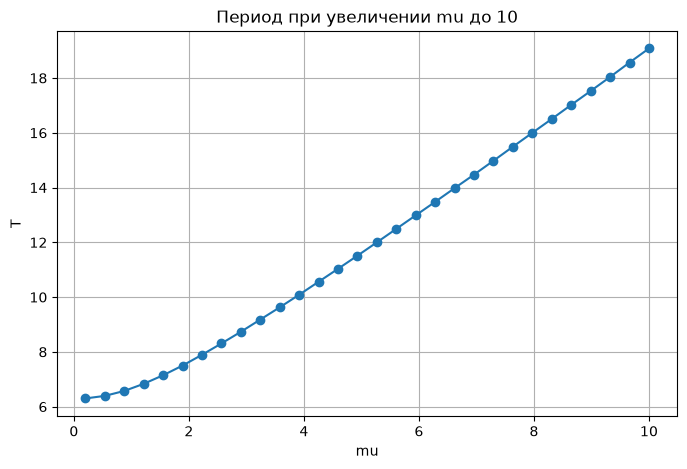

In [22]:
# Ваш код для задания 6

mu_values = np.linspace(0.2, 10.0, 30)

periods = []

for mu_value in mu_values:
    _, T = cycle_stats(
        mu_value,
        t_end=400,
        t_cut=200,
    )

    periods.append(T)


plt.figure(figsize=(8, 5))

plt.plot(mu_values, periods, marker='o')

plt.xlabel('mu')
plt.ylabel('T')
plt.title('Период при увеличении mu до 10')
plt.grid()

plt.show()

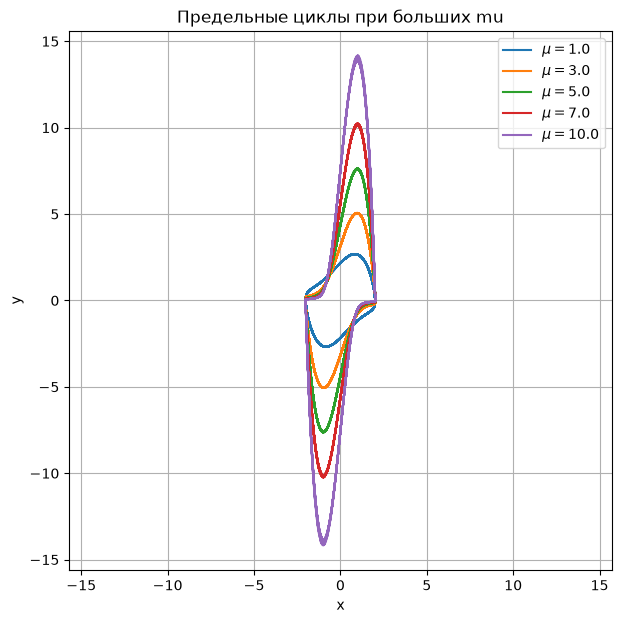

In [23]:
mu_phase = [1.0, 3.0, 5.0, 7.0, 10.0]

plt.figure(figsize=(7, 7))

for mu_value in mu_phase:
    x_cycle, y_cycle = settled_cycle(
        mu_value,
        t_end=400,
        t_cut=200,
    )

    plt.plot(
        x_cycle,
        y_cycle,
        label=fr'$\mu={mu_value}$',
    )

plt.xlabel('x')
plt.ylabel('y')
plt.title('Предельные циклы при больших mu')
plt.axis('equal')
plt.grid()
plt.legend()

plt.show()

<span style="color:red">Ответ:</span>

1. при увеличении $\mu$ до $10$ период колебаний продолжает монотонно расти, причём при больших $\mu$ рост становится более выраженным
2. максимальное значение $|x|$ меняется незначительно
3. форма предельного цикла при росте $\mu$ заметно меняется: цикл всё сильнее вытягивается по оси $y$, что соответствует появлению более резких переходов в решении
4. таким образом, увеличение $\mu$ гораздо сильнее влияет на период и форму колебаний, чем на их амплитуду по координате $x$

## Итог

В конце notebook напишите **8–12 предложений** по результатам домашней работы.

Не пересказывайте условие. Напишите, что реально получилось в расчётах:

- как меняются амплитуда, период и форма цикла при изменении $\mu$;
- как начальное условие влияет на переходный процесс;
- насколько совпадают два способа оценки периода;
- что получилось при сравнении методов `solve_ivp`;
- что вы увидели в самостоятельном эксперименте.

## Перед сдачей

- выполните `Restart Kernel → Run All`;
- notebook должен выполняться сверху вниз без ошибок;
- подпишите оси и легенды;
- не дублируйте большие куски кода;
- не пишите численные результаты «на глаз» — всё, что указано числом, должно считаться кодом;
- после каждого задания оставьте короткий вывод своими словами.

<span style="color:red">Ответ:</span>

В ходе работы получилось увидеть, что при увеличении $\mu$ амплитуда колебаний по $x$ меняется совсем немного и остаётся примерно на одном уровне, а период при этом заметно растёт. Одновременно с этим сильно меняется и сама форма предельного цикла: при больших $\mu$ он становится более вытянутым, а временной сигнал приобретает выраженный релаксационный характер. Разные начальные условия влияют в основном на переходный процесс: к установившемуся режиму решения подходят с разной скоростью, но в итоге выходят на один и тот же цикл. Два способа вычисления периода — по максимумам и по событиям пересечения $x=0$ — дали практически одинаковые результаты. Небольшое различие между ними связано с тем, что `find_peaks` работает по дискретным точкам, а `events` точнее локализует момент пересечения. При сравнении методов `solve_ivp` все три solver'а успешно дали одинаковый период, но заметно отличались по числу вычислений правой части. В наших расчётах наиболее экономным по `nfev` оказался `DOP853`. При больших $\mu$ задача становится сложнее, потому что в решении одновременно появляются медленные участки и быстрые переходы. В самостоятельном эксперименте при продолжении расчётов до $\mu=10$ период продолжил расти, а форма цикла стала ещё более вытянутой. При этом максимальное значение $|x|$ по-прежнему менялось значительно слабее, чем период и форма цикла.